In [2]:
# Erstmal notwendige Bibliotheken laden

import graphviz
import pm4py
from pm4py.objects.petri_net.utils import initial_marking
from pm4py.visualization.transition_system.util.visualize_graphviz import visualize

In [9]:
# Daten reinladen
# Pfad bitte anpassen, falls ihr es bei euch laufen lasst.
dataframe = df = pm4py.read_xes('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-06 TYT_event_log V2.0 filtered.xes')

parsing log, completed traces :: 100%|██████████| 1274/1274 [00:00<00:00, 1936.06it/s]


In [4]:
df.head()

,concept:name,time:timestamp,age,gender,sound_env,case:concept:name
0,medium,2015-04-11 21:40:00+00:00,33.0,1.0,0.001390,1002
1,low,2015-04-12 16:25:00+00:00,33.0,1.0,0.001071,1002
2,low,2015-04-13 18:17:00+00:00,33.0,1.0,0.038022,1002
3,low,2015-04-14 08:04:00+00:00,33.0,1.0,0.002037,1002
4,low,2015-04-19 08:15:00+00:00,33.0,1.0,0.001909,1002


In [5]:
print(df.isna().sum())

concept:name            0
time:timestamp          0
age                  1608
gender               2549
sound_env            2145
case:concept:name       0
dtype: int64


# Mining anwenden und Grafiken ausgeben

In [ ]:
# Abkürzungen

# im = initial_marking
# fm = final_marking
# alpha_m = Alpha Miner
# heuristic_m = Heuristic Miner
# inductive_m = Inductive Miner
# ilp_m = ILP Miner
# dfg_m = DFG Miner
# genetic_m = Genetic Miner
# Alpha Miner

In [10]:
log = df.copy()

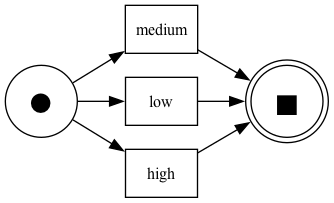

In [11]:
from pm4py.algo.discovery.alpha import algorithm as alpha_miner

net_alpha_m, im_alpha_m, fm_alpha_m = alpha_miner.apply(log)
pm4py.view_petri_net(net_alpha_m, im_alpha_m, fm_alpha_m)

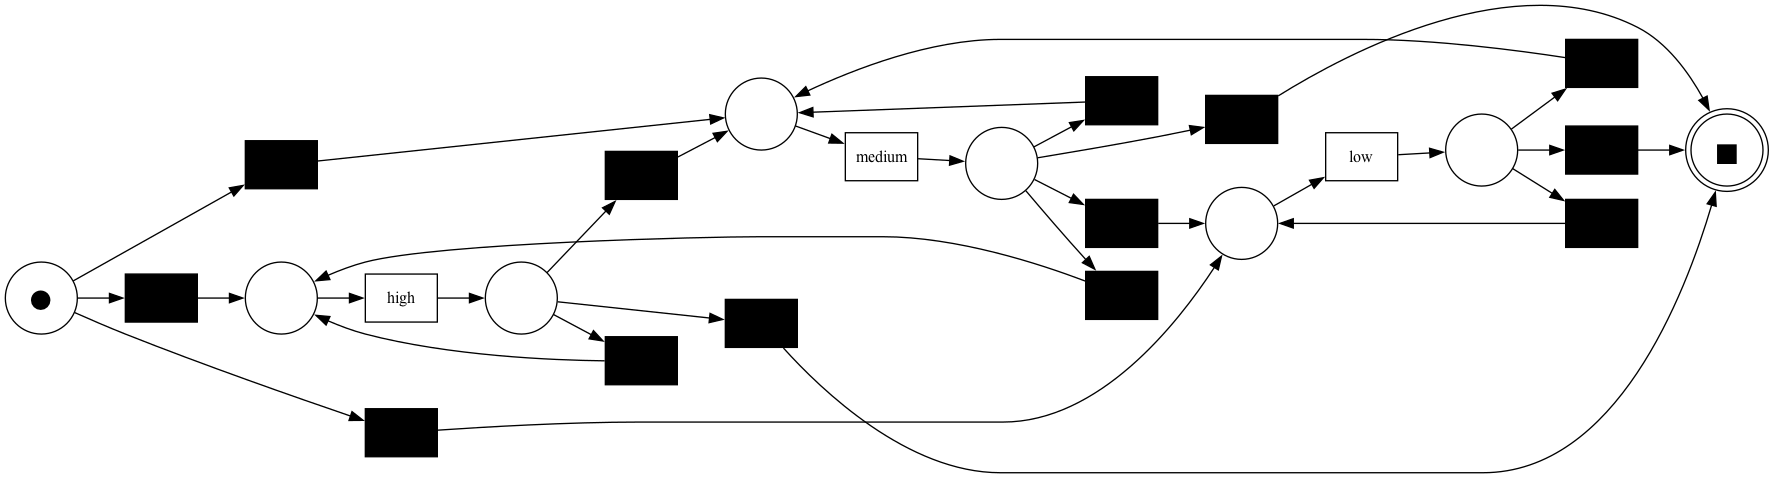

In [31]:
# Heuristic Miner
from pm4py.algo.discovery.heuristics import algorithm as heuristic_miner

net_heuristic_m, im_heuristic_m, fm_heuristic_m = heuristic_miner.apply(log)
pm4py.view_petri_net(net_heuristic_m, im_heuristic_m, fm_heuristic_m)

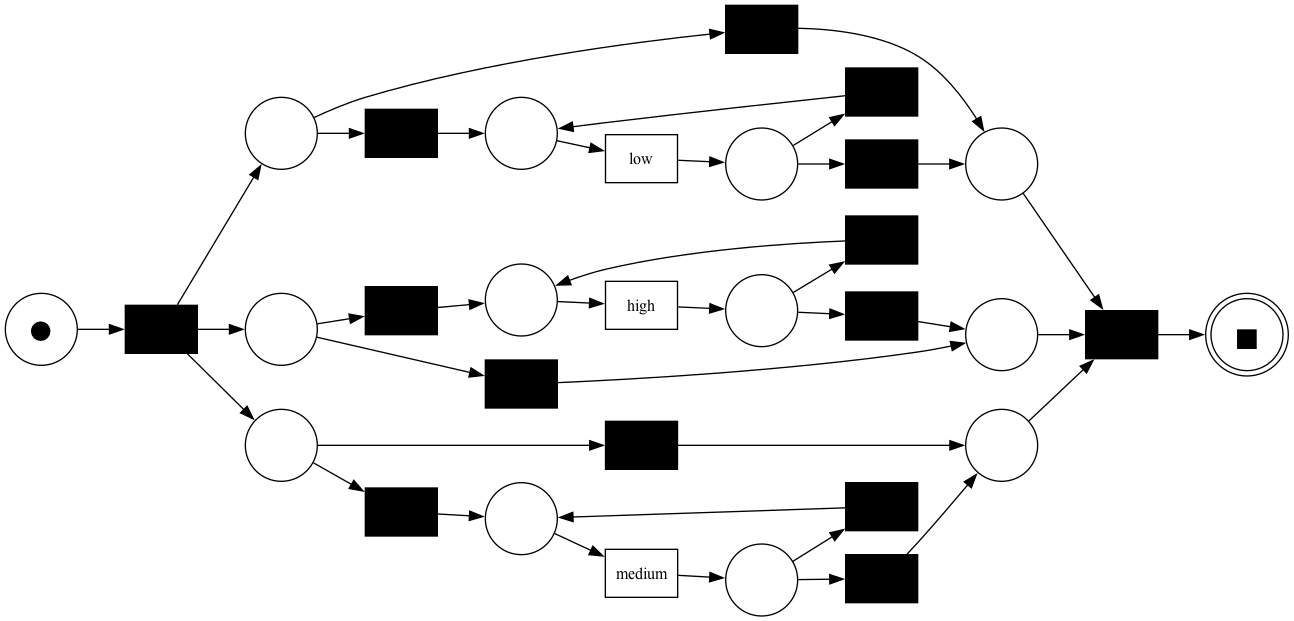

In [32]:
# Inductive Miner
from pm4py.algo.discovery.inductive import algorithm as inductive_miner

tree = inductive_miner.apply(log)
net_inductive_m, im_inductive_m, fm_inductive_m = pm4py.convert_to_petri_net(tree)
pm4py.view_petri_net(net_inductive_m, im_inductive_m, fm_inductive_m)

In [ ]:
# ILP Miner

# lief 22min und es ging nicht voran

# PuLP NICHT installieren, dann geht der Codeblock nicht mehr!!
'''
from pm4py.algo.discovery.ilp import algorithm as ilp_miner

net_ilp_m, im_ilp_m, fm_ilp_m = ilp_miner.apply(log)
pm4py.view_petri_net(net_ilp_m, im_ilp_m, fm_ilp_m)'''

In [7]:
# DFG (Directly-Follows-Graph) anstelle von Fuzzy Miner als Approximation
# PM4Py hat keinen Fuzzy Miner, höchstens ProM

# DFG (Directly Follows Graph) mit Häufigkeiten/Durchlaufzeiten und unterschiedlicher Pfeildicke
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery

dfg = dfg_discovery.apply(log)

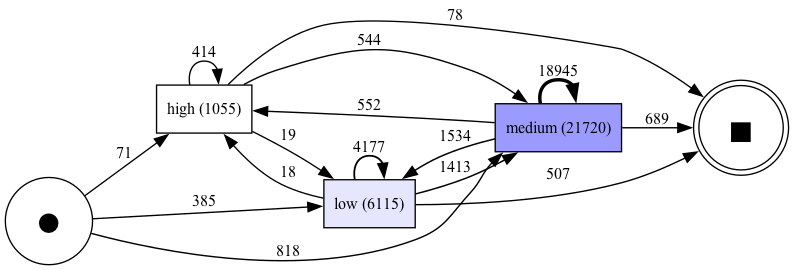

In [12]:
# Visualisierung mit Häufigkeiten
from pm4py.statistics.start_activities.log import get as start_activities
from pm4py.statistics.end_activities.log import get as end_activities

start_acts = start_activities.get_start_activities(log)
end_acts = end_activities.get_end_activities(log)

from pm4py.visualization.dfg import visualizer as dfg_visualization

gviz = dfg_visualization.apply(
    dfg,
    log=log,
    variant=dfg_visualization.Variants.FREQUENCY,
    parameters={
        "start_activities": start_acts,
        "end_activities": end_acts
    }
)

dfg_visualization.view(gviz)

In [13]:
# Fitness, Precision, Generalisation und Simplicity
from pm4py.algo.evaluation.replay_fitness import algorithm as replay_fitness
from pm4py.algo.evaluation.precision import algorithm as precision_evaluator
from pm4py.algo.evaluation.generalization import algorithm as generalization_evaluator
from pm4py.algo.evaluation.simplicity import algorithm as simplicity_evaluator

In [35]:
# Evaluierung als Definition, um das später leichter zu haben.
# Wählt eigenständig den Token Based Replay oder Alignment für Fitness für den jeweiligen Miner!

def evaluate_model(log, net, im, fm):
    fitness_result = replay_fitness.apply(log, net, im, fm)
    precision = precision_evaluator.apply(log, net, im, fm)
    generalization = generalization_evaluator.apply(log, net, im, fm)
    simplicity = simplicity_evaluator.apply(net)

    fitness_value = fitness_result.get('log_fitness') or fitness_result.get('average_trace_fitness')

    print(f"Fitness: {fitness_result}"),
    print(f"Precision: {precision * 100:.4f}%"),
    print(f"Generalization: {generalization :.4f}"),
    print(f"Simplicity: {simplicity :.4f}")

    # Rückgabe als Dictionary für Tabelle
    return {
        "Fitness": fitness_value,
        "Precision": precision,
        "Generalization": generalization,
        "Simplicity": simplicity
    }

# Dictionary zum Speichern der Ergebnisse
all_results = {}

In [ ]:
# Evaluierung Alpha Miner
print(f'Alpha Miner')
all_results['Alpha'] = evaluate_model(log, net_alpha_m, im_alpha_m, fm_alpha_m)

Alpha Miner



aligning log, completed variants :: 100%|██████████| 250/250 [00:17<00:00, 14.34it/s]


In [16]:
# Evaluierung Heuristic Miner
print(f'Heuristic Miner')
all_results['Heuristic'] = evaluate_model(log, net_heuristic_m, im_heuristic_m, fm_heuristic_m)

Heuristic Miner


aligning log, completed variants :: 100%|██████████| 100/100 [00:00<00:00, 795.54it/s]
computing precision with alignments, completed variants :: 100%|██████████| 130/130 [00:00<00:00, 488.12it/s]
replaying log with TBR, completed traces :: 100%|██████████| 100/100 [00:00<00:00, 3822.18it/s]

Fitness: {'percFitTraces': 99.90846681922197, 'averageFitness': 0.9997711670480549, 'percentage_of_fitting_traces': 99.90846681922197, 'average_trace_fitness': 0.9997711670480549, 'log_fitness': 0.9996491977048292}
Precision: 88.4908%
Generalization: 0.9193
Simplicity: 0.6000


In [17]:
# Evaluierung Inductive Miner
print(f'Inductive Miner')
all_results['Inductive'] = evaluate_model(log, net_inductive_m, im_inductive_m, fm_inductive_m)

Inductive Miner


aligning log, completed variants :: 100%|██████████| 100/100 [00:00<00:00, 337.64it/s]
computing precision with alignments, completed variants :: 100%|██████████| 130/130 [00:00<00:00, 145.19it/s]
replaying log with TBR, completed traces :: 100%|██████████| 100/100 [00:00<00:00, 3436.04it/s]

Fitness: {'percFitTraces': 100.0, 'averageFitness': 1.0, 'percentage_of_fitting_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 0.9997341797385813}
Precision: 86.0095%
Generalization: 0.9426
Simplicity: 0.6889


In [ ]:
# Evaluierung ILP Miner
'''print(f'ILP Miner')
all_results['ILP'] = evaluate_model(log, net_ilp_m, im_ilp_m, fm_ilp_m)'''

In [18]:
# Evaluierung DFG

# testen, ob sich das dann evaluieren lässt -> ja das klappt. Macht das dann überhaupt Sinn oder weicht das vom eigentlichen Output von oben ab?
# Chattie sagt nämlich, dass die Konvertierung: heuristisch ist, Struktur verzerren kann und Metriken beeinflusst
from pm4py.objects.conversion.dfg import converter as dfg_converter

net_dfg, im_dfg, fm_dfg = dfg_converter.apply(dfg)

print("DFG (converted)")
all_results['DFG (converted)'] = evaluate_model(log, net_dfg, im_dfg, fm_dfg)

DFG (converted)


replaying log with TBR, completed traces :: 100%|██████████| 100/100 [00:00<00:00, 5473.16it/s]

Fitness: {'perc_fit_traces': 0.0, 'average_trace_fitness': 0.27160310496585954, 'log_fitness': 0.4519001630502948, 'percentage_of_fitting_traces': 0.0}
Precision: 100.0000%
Generalization: 0.8255
Simplicity: 0.6842


In [ ]:
# Evaluierung Genetic Miner
# aktivieren wenn der Genetic Miner auch ausgeführt wird

#print(f'Genetic Miner')
#all_results['Genetic'] = evaluate_model(log, net_genetic_m, im_genetic_m, fm_genetic_m)
# Pandas DataFrames aus Dictionary erstellen

In [19]:
import pandas as pd
df_comparison = pd.DataFrame.from_dict(all_results, orient='index')

# Formatierung für die Anzeige (% und :.4f)
df_display = df_comparison.copy()
for col in ["Fitness", "Precision"]:
    df_display[col] = df_display[col].apply(lambda x: f"{x * 100:.2f}%")

for col in ["Generalization", "Simplicity"]:
    df_display[col] = df_display[col].apply(lambda x: f"{x:.4f}")

print("Übersicht:")
print(df_display)
# oder display(df_display)

Übersicht:
                Fitness Precision Generalization Simplicity
Alpha            54.81%   100.00%         0.9568     0.7143
Heuristic        99.96%    88.49%         0.9193     0.6000
Inductive        99.97%    86.01%         0.9426     0.6889
DFG (converted)  45.19%   100.00%         0.8255     0.6842
